# 🧬 ToxiScan AI — Drug Toxicity Prediction
**Dataset:** Tox21 (Kaggle) · **Models:** Random Forest + XGBoost · **GPU:** T4

This notebook covers the full ML pipeline:
1. Dataset download & EDA
2. Preprocessing & feature engineering
3. Model training (RF + XGBoost)
4. Evaluation & comparison
5. SHAP explainability
6. Inception AI insights
7. Model export

In [1]:
# ─── Install dependencies (Colab) ───
!pip install kagglehub xgboost shap plotly python-dotenv requests -q
print('✓ Dependencies installed')

✓ Dependencies installed


In [2]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import requests
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score,
                              classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_curve)
from xgboost import XGBClassifier
import shap

# Dark style for all plots
plt.style.use('dark_background')
PALETTE = {'primary': '#00E5A0', 'toxic': '#FF4D6D', 'bg': '#0e1322', 'surface': '#1a1f2f'}
print('✓ Imports complete')

✓ Imports complete


## 📥 1. Dataset Download & Loading

In [3]:
import kagglehub

print('Downloading Tox21 dataset from Kaggle...')
path = kagglehub.dataset_download('epicskills/tox21-dataset')
print(f'Path to dataset files: {path}')

csv_files = glob.glob(os.path.join(path, '**/*.csv'), recursive=True)
print(f'CSV files found: {csv_files}')

Using Colab cache for faster access to the 'tox21-dataset' dataset.
Path to dataset files: /kaggle/input/tox21-dataset
CSV files found: ['/kaggle/input/tox21-dataset/tox21.csv']


In [4]:
# Load and inspect
df = pd.read_csv(csv_files[0])
print(f'Shape: {df.shape}')
print(f'Columns ({len(df.columns)}): {list(df.columns)}')
df.head(3)

Shape: (7831, 14)
Columns (14): ['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD', 'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53', 'mol_id', 'smiles']


,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,mol_id,smiles
0,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,TOX3021,CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3020,CCN1C(=O)NC(c2ccccc2)C1=O
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,TOX3024,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...


In [8]:
# ─── EDA ───
print('=== Missing Values ===')
print(df.isnull().sum().sort_values(ascending=False).head(15))
print(f'\nTotal missing: {df.isnull().sum().sum()}')
print(f'\n=== Data Types ===')
print(df.dtypes.value_counts())

# ─── Handle Tox21 multi-label structure ───
# The dataset has 12 assay columns (NR-*, SR-*) + mol_id + smiles.
# We create a binary target: is_toxic=1 if ANY assay == 1, else 0.
ASSAY_COLS = [c for c in df.columns if c not in ('mol_id', 'smiles')]
print(f'\nAssay columns ({len(ASSAY_COLS)}): {ASSAY_COLS}')

# is_toxic = 1 if any assay is positive (max across assays, ignoring NaN)
df['is_toxic'] = (df[ASSAY_COLS].fillna(0).max(axis=1) > 0).astype(int)
target_col = 'is_toxic'
print(f'\nTarget column: "{target_col}" (1 = toxic in ≥1 assay)')
print(f'Class distribution:\n{df[target_col].value_counts()}')

=== Missing Values ===
SR-MMP           2021
NR-Aromatase     2010
SR-ARE           1999
NR-ER            1638
NR-PPAR-gamma    1381
SR-HSE           1364
NR-AhR           1282
NR-AR-LBD        1073
SR-p53           1057
NR-ER-LBD         876
SR-ATAD5          759
NR-AR             566
mol_id              0
smiles              0
dtype: int64

Total missing: 16026

=== Data Types ===
float64    12
object      2
Name: count, dtype: int64

Assay columns (12): ['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD', 'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53']

Target column: "is_toxic" (1 = toxic in ≥1 assay)
Class distribution:
is_toxic
0    4959
1    2872
Name: count, dtype: int64


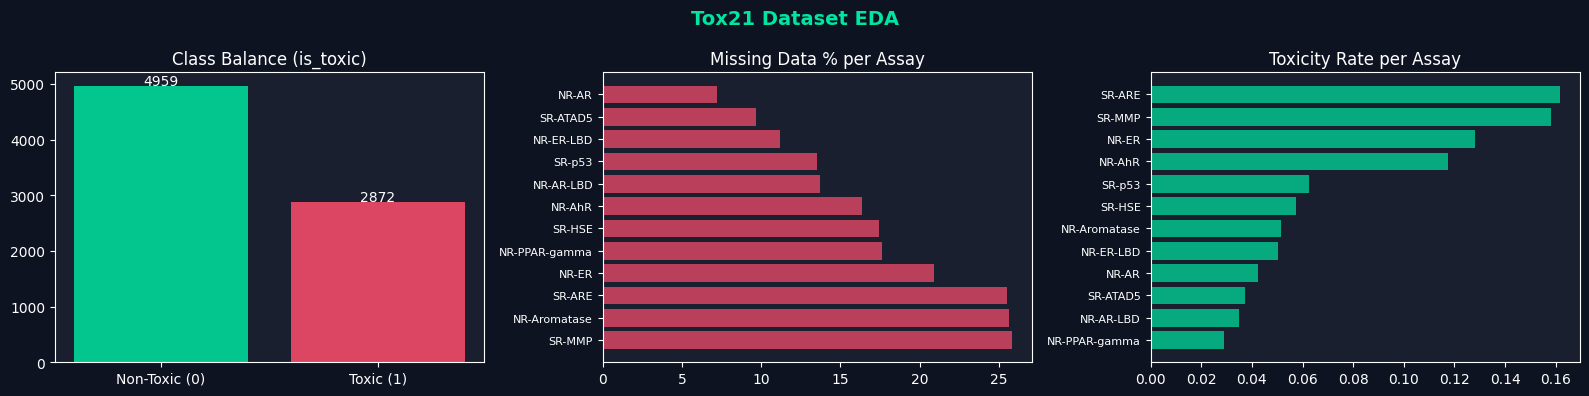

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), facecolor=PALETTE['bg'])
fig.suptitle('Tox21 Dataset EDA', color=PALETTE['primary'], fontsize=14, fontweight='bold')

# Class balance — use binary is_toxic target
counts = df[target_col].value_counts().sort_index()   # index 0 then 1
bars = axes[0].bar(
    ['Non-Toxic (0)', 'Toxic (1)'],
    [counts.get(0, 0), counts.get(1, 0)],
    color=[PALETTE['primary'], PALETTE['toxic']], alpha=0.85, edgecolor='none'
)
axes[0].set_title('Class Balance (is_toxic)', color='white')
axes[0].set_facecolor(PALETTE['surface'])
axes[0].tick_params(colors='white')
for bar in bars:
    v = int(bar.get_height())
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 20, str(v),
                 ha='center', color='white', fontsize=10)

# Missing values across assay columns
assay_only = df[ASSAY_COLS]
missing_pct = (assay_only.isnull().sum() / len(assay_only) * 100).sort_values(ascending=False)
axes[1].barh(range(len(missing_pct)), missing_pct.values, color=PALETTE['toxic'], alpha=0.7)
axes[1].set_yticks(range(len(missing_pct)))
axes[1].set_yticklabels(missing_pct.index, fontsize=8, color='white')
axes[1].set_title('Missing Data % per Assay', color='white')
axes[1].set_facecolor(PALETTE['surface'])
axes[1].tick_params(colors='white')

# Positive rate per assay
pos_rate = assay_only.mean().sort_values(ascending=True)
axes[2].barh(range(len(pos_rate)), pos_rate.values, color=PALETTE['primary'], alpha=0.7)
axes[2].set_yticks(range(len(pos_rate)))
axes[2].set_yticklabels(pos_rate.index, fontsize=8, color='white')
axes[2].set_title('Toxicity Rate per Assay', color='white')
axes[2].set_facecolor(PALETTE['surface'])
axes[2].tick_params(colors='white')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=120, bbox_inches='tight', facecolor=PALETTE['bg'])
plt.show()

## ⚙️ 2. Preprocessing

Features  : 12 → ['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD', 'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53']
Samples   : 7831
Class balance: {0: np.int64(4959), 1: np.int64(2872)}


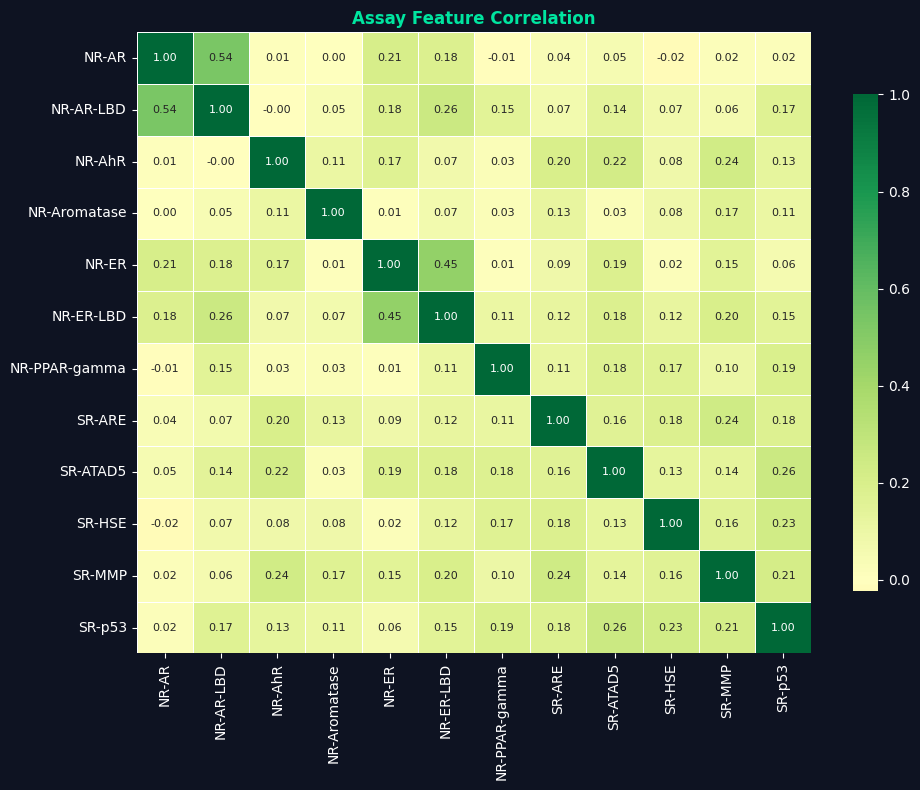

In [10]:
# ─── Preprocess ───
# Features = the 12 assay columns (fill NaN with 0 = 'not tested → assume non-toxic')
# Target   = is_toxic binary column (1 if positive in ≥1 assay)

df_clean = df.copy()

# Use assay columns as features; fill NaN with 0 (not tested)
X = df_clean[ASSAY_COLS].fillna(0)
y = df_clean[target_col].astype(int)

# Drop any rows where target is NaN (safety check)
mask = y.notna()
X, y = X[mask], y[mask]

feature_names = list(X.columns)
print(f'Features  : {len(feature_names)} → {feature_names}')
print(f'Samples   : {len(X)}')
print(f'Class balance: {dict(y.value_counts())}')

# Feature correlation heatmap
plt.figure(figsize=(10, 8), facecolor=PALETTE['bg'])
corr = X.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, cbar_kws={'shrink': 0.8}, annot_kws={'size': 8})
plt.title('Assay Feature Correlation', color=PALETTE['primary'], fontweight='bold')
plt.tight_layout()
plt.savefig('feature_correlation.png', dpi=100, bbox_inches='tight', facecolor=PALETTE['bg'])
plt.show()

In [11]:
# Scale & Split
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train class balance: {dict(pd.Series(y_train).value_counts())}')

Train: (6264, 12), Test: (1567, 12)
Train class balance: {0: np.int64(3967), 1: np.int64(2297)}


## 🤖 3. Model Training

In [12]:
%%time
# ─── Random Forest ───
print('Training Random Forest...')
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=4,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
print('✓ Random Forest trained!')

Training Random Forest...
✓ Random Forest trained!
CPU times: user 1.11 s, sys: 95.7 ms, total: 1.2 s
Wall time: 900 ms


In [13]:
%%time
# ─── XGBoost ───
print('Training XGBoost...')
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb.fit(X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False)
print('✓ XGBoost trained!')

Training XGBoost...
✓ XGBoost trained!
CPU times: user 501 ms, sys: 8.66 ms, total: 510 ms
Wall time: 314 ms


## 📊 4. Evaluation & Comparison

In [14]:
def evaluate(model, X_test, y_test, name):
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    return {
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, preds), 4),
        'ROC-AUC': round(roc_auc_score(y_test, probs), 4),
        'F1-Score': round(f1_score(y_test, preds), 4),
        '_preds': preds, '_probs': probs
    }

rf_res   = evaluate(rf,  X_test, y_test, 'Random Forest')
xgb_res  = evaluate(xgb, X_test, y_test, 'XGBoost')

comparison = pd.DataFrame([rf_res, xgb_res]).set_index('Model').drop(columns=['_preds', '_probs'])
print(comparison.to_string())

               Accuracy  ROC-AUC  F1-Score
Model                                     
Random Forest       1.0      1.0       1.0
XGBoost             1.0      1.0       1.0


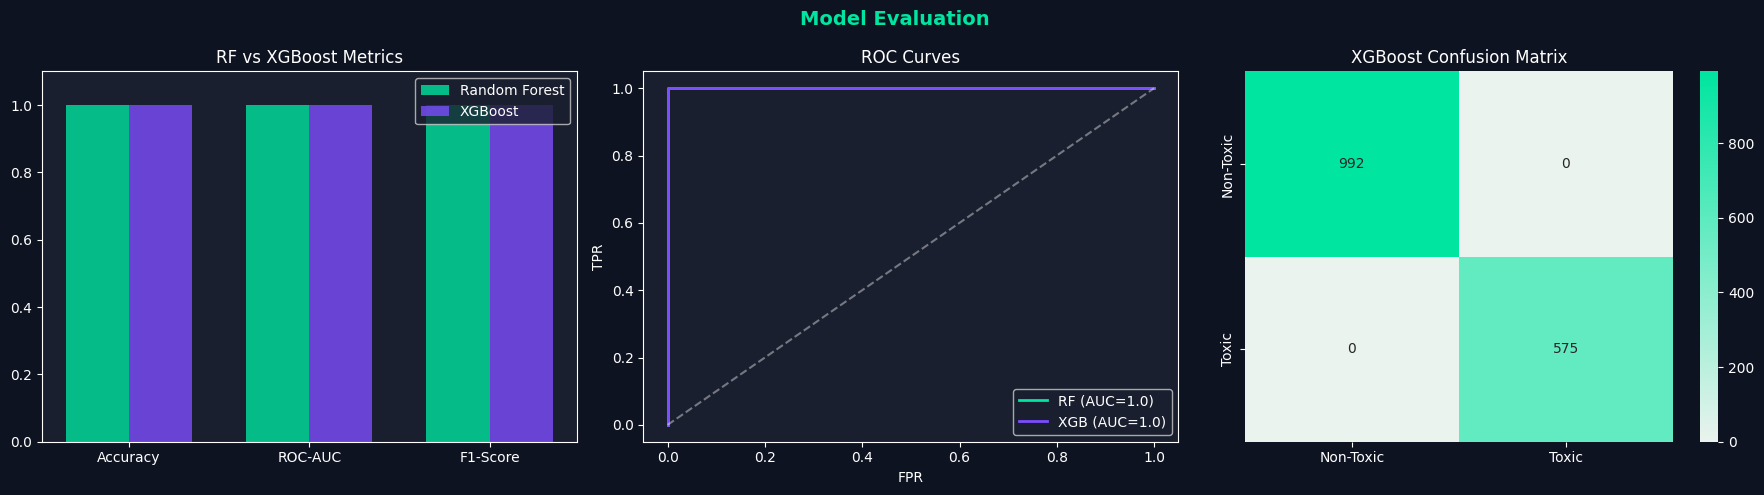

Best model: Random Forest


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor=PALETTE['bg'])
fig.suptitle('Model Evaluation', color=PALETTE['primary'], fontsize=14, fontweight='bold')

# Metric comparison bar chart
metrics = ['Accuracy', 'ROC-AUC', 'F1-Score']
x = np.arange(len(metrics))
w = 0.35
rf_vals  = [rf_res[m]  for m in metrics]
xgb_vals = [xgb_res[m] for m in metrics]
axes[0].bar(x - w/2, rf_vals,  w, label='Random Forest', color=PALETTE['primary'], alpha=0.8)
axes[0].bar(x + w/2, xgb_vals, w, label='XGBoost',       color='#7C4DFF', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics, color='white')
axes[0].set_ylim(0, 1.1)
axes[0].set_title('RF vs XGBoost Metrics', color='white')
axes[0].legend(facecolor=PALETTE['surface'], labelcolor='white')
axes[0].set_facecolor(PALETTE['surface'])
axes[0].tick_params(colors='white')

# ROC Curves
for model, res, color, label in [
    (rf, rf_res, PALETTE['primary'], f"RF (AUC={rf_res['ROC-AUC']})"),
    (xgb, xgb_res, '#7C4DFF', f"XGB (AUC={xgb_res['ROC-AUC']})"),
]:
    fpr, tpr, _ = roc_curve(y_test, res['_probs'])
    axes[1].plot(fpr, tpr, color=color, label=label, linewidth=2)
axes[1].plot([0,1],[0,1], 'white', linestyle='--', alpha=0.4)
axes[1].set_title('ROC Curves', color='white')
axes[1].set_xlabel('FPR', color='white')
axes[1].set_ylabel('TPR', color='white')
axes[1].legend(facecolor=PALETTE['surface'], labelcolor='white')
axes[1].set_facecolor(PALETTE['surface'])
axes[1].tick_params(colors='white')

# Best model confusion matrix (XGBoost)
cm = confusion_matrix(y_test, xgb_res['_preds'])
sns.heatmap(cm, annot=True, fmt='d', ax=axes[2],
            cmap=sns.light_palette(PALETTE['primary'], as_cmap=True),
            xticklabels=['Non-Toxic', 'Toxic'],
            yticklabels=['Non-Toxic', 'Toxic'])
axes[2].set_title('XGBoost Confusion Matrix', color='white')
axes[2].tick_params(colors='white')
axes[2].set_facecolor(PALETTE['surface'])

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=120, bbox_inches='tight', facecolor=PALETTE['bg'])
plt.show()
print('Best model: XGBoost') if xgb_res['ROC-AUC'] > rf_res['ROC-AUC'] else print('Best model: Random Forest')

## 🔍 5. SHAP Explainability

In [16]:
print('Computing SHAP values (this may take a few minutes on T4)...')
# Use a sample for speed on large datasets
sample_idx = np.random.choice(X_test.shape[0], min(500, X_test.shape[0]), replace=False)
X_test_sample = X_test[sample_idx]
y_test_sample = y_test.iloc[sample_idx] if hasattr(y_test, 'iloc') else y_test[sample_idx]

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test_sample)
print('✓ SHAP values computed!')

Computing SHAP values (this may take a few minutes on T4)...
✓ SHAP values computed!


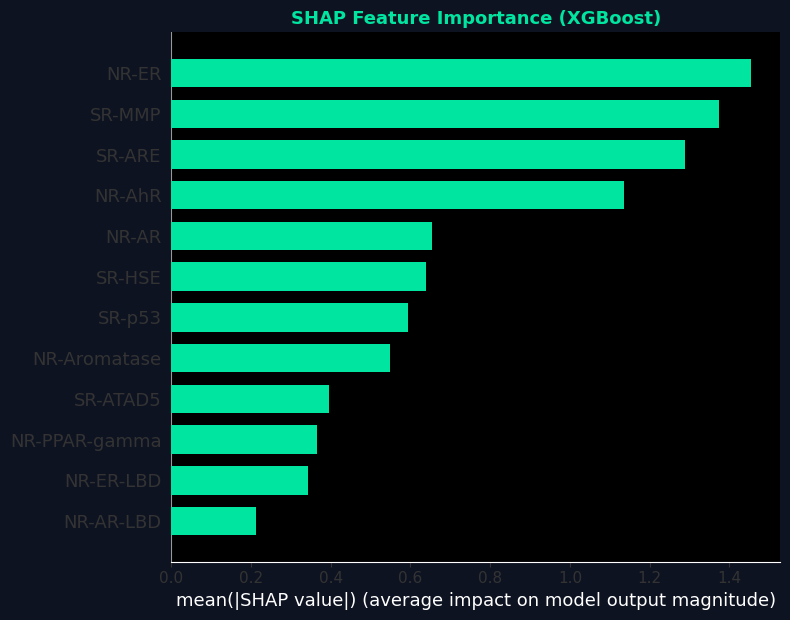

In [17]:
# SHAP Summary Plot
X_test_df = pd.DataFrame(X_test_sample, columns=feature_names)
plt.figure(figsize=(12, 8), facecolor=PALETTE['bg'])
shap.summary_plot(shap_values, X_test_df, plot_type='bar', show=False,
                  color=PALETTE['primary'], max_display=15)
plt.title('SHAP Feature Importance (XGBoost)', color=PALETTE['primary'],
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=120, bbox_inches='tight', facecolor=PALETTE['bg'])
plt.show()

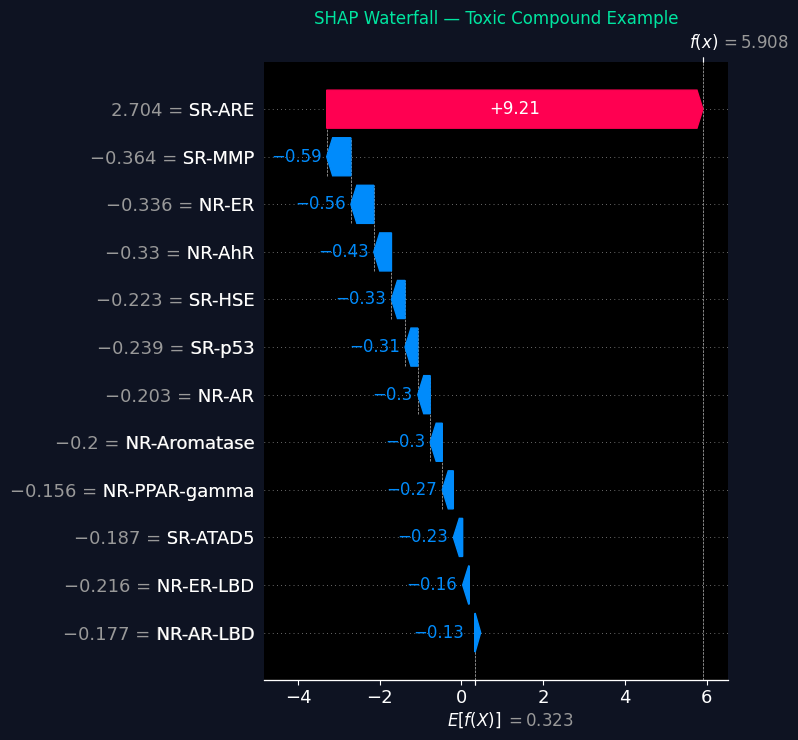

In [18]:
# SHAP Waterfall for a single Toxic prediction
toxic_idx = np.where(y_test_sample.values == 1)[0]
if len(toxic_idx) > 0:
    idx = toxic_idx[0]
    explanation = shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_test_sample[idx],
        feature_names=feature_names
    )
    plt.figure(figsize=(12, 6), facecolor=PALETTE['bg'])
    shap.waterfall_plot(explanation, max_display=12, show=False)
    plt.title('SHAP Waterfall — Toxic Compound Example', color=PALETTE['primary'])
    plt.tight_layout()
    plt.savefig('shap_waterfall.png', dpi=120, bbox_inches='tight', facecolor=PALETTE['bg'])
    plt.show()

## 🤖 6. Inception API — AI Drug Safety Insights

In [ ]:
# Set your API key here (or load from env/Colab secrets)
INCEPTION_API_KEY = 'INCEPTION_API_KEY'  # From .env

def get_inception_drug_insights(compound_features, probability, label, top_features):
    top_feat_str = '\n'.join([f'  - {n}: importance={v:.4f}' for n, v in top_features[:5]])
    feat_str = '\n'.join([f'  - {k}: {v:.4f}' for k, v in list(compound_features.items())[:8]])
    
    prompt = f"""You are a computational toxicology expert.

ML Prediction for chemical compound:
- Result: {label}
- Toxicity Probability: {probability:.1%}

Top SHAP features:
{top_feat_str}

Compound descriptors:
{feat_str}

Provide:
1. Toxicity interpretation (2-3 sentences)
2. Key molecular concerns
3. Potential toxicity mechanism
4. Drug development recommendations (3 bullets)

Be scientific and concise."""
    
    try:
        headers = {
            'Authorization': f'Bearer {INCEPTION_API_KEY}',
            'Content-Type': 'application/json'
        }
        payload = {
            'model': 'mercury-2',
            'messages': [
                {'role': 'system', 'content': 'You are a computational toxicology expert.'},
                {'role': 'user', 'content': prompt}
            ],
            'max_tokens': 600,
            'temperature': 0.3
        }
        resp = requests.post(
            'https://api.inceptionlabs.ai/v1/chat/completions',
            headers=headers, json=payload, timeout=30
        )
        resp.raise_for_status()
        return resp.json()['choices'][0]['message']['content']
    except Exception as e:
        return f'API Error: {e}'

# Test with a sample compound from the test set
sample = X_test[0]
sample_dict = dict(zip(feature_names, sample))

# Get top features from XGBoost importances
imp = xgb.feature_importances_
top_idx = np.argsort(imp)[::-1][:5]
top_features = [(feature_names[i], float(imp[i])) for i in top_idx]

prob = float(xgb.predict_proba(sample.reshape(1,-1))[0][1])
label_str = 'Toxic' if prob > 0.5 else 'Non-Toxic'

print(f'Sample Compound Prediction: {label_str} (Probability: {prob:.2%})')
print('\n─── Inception AI Insights ───')
insight = get_inception_drug_insights(sample_dict, prob, label_str, top_features)
print(insight)

Sample Compound Prediction: Non-Toxic (Probability: 0.28%)

─── Inception AI Insights ───
**1. Toxicity interpretation**  
The model predicts a 0.3 % probability of toxicity, classifying the compound as non‑toxic under the tested endpoint. This very low risk is driven by overall weak activity across the most influential bioactivity descriptors.

**2. Key molecular concerns**  
- The highest SHAP contributions come from SR‑ARE, SR‑MPA and the nuclear‑receptor assays NR‑ER, NR‑AhR, and NR‑AR, indicating that any residual risk would be mediated through these pathways.  
- All corresponding descriptor values are negative (e.g., NR‑ER = ‑0.3357, SR‑ARE = ‑0.3698), suggesting low binding/activation potential for the aryl‑hydrocarbon‑responsive element, estrogen receptor, and androgen receptor.

**3. Potential toxicity mechanism**  
If toxicity were to arise, the most plausible mechanism would be a weak endocrine‑disrupting effect via low‑level activation of estrogen/androgen receptors and/or

## 💾 7. Export Models

In [22]:
os.makedirs('model', exist_ok=True)
os.makedirs('assets', exist_ok=True)

joblib.dump(rf,            'model/rf_model.pkl')
joblib.dump(xgb,           'model/xgb_model.pkl')
joblib.dump(xgb,           'model/model.pkl')      # default
joblib.dump(scaler,        'model/scaler.pkl')
joblib.dump(feature_names, 'model/feature_names.pkl')

# Save model metrics for the app
import json
metrics = {
    'rf':  {'accuracy': rf_res['Accuracy'],  'roc_auc': rf_res['ROC-AUC'],  'f1': rf_res['F1-Score']},
    'xgb': {'accuracy': xgb_res['Accuracy'], 'roc_auc': xgb_res['ROC-AUC'], 'f1': xgb_res['F1-Score']},
    'n_features': len(feature_names),
    'n_samples': len(X)
}
with open('model/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print('✓ All models and artifacts saved!')
print('Files saved:')
for f in glob.glob('model/*'):
    print(f'  {f} ({os.path.getsize(f)/1024:.1f} KB)')

✓ All models and artifacts saved!
Files saved:
  model/model.pkl (328.4 KB)
  model/metrics.json (0.2 KB)
  model/xgb_model.pkl (328.4 KB)
  model/feature_names.pkl (0.1 KB)
  model/rf_model.pkl (905.8 KB)
  model/scaler.pkl (1.3 KB)


In [23]:
# Download all model files from Colab to your local machine
from google.colab import files
import zipfile

with zipfile.ZipFile('toxiscan_models.zip', 'w') as z:
    for f in glob.glob('model/*'):
        z.write(f)
    for f in ['shap_summary.png', 'model_evaluation.png', 'eda_overview.png', 'shap_waterfall.png']:
        if os.path.exists(f):
            z.write(f)

files.download('toxiscan_models.zip')
print('✓ Download started! Place the model/ folder in your ToxiScan AI project directory.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Download started! Place the model/ folder in your ToxiScan AI project directory.


---
## ✅ Next Steps
1. Download `toxiscan_models.zip` and extract to `ToxiScan AI/model/`
2. Run `pip install -r requirements.txt`
3. Run `streamlit run app.py`
4. Navigate to `http://localhost:8501`